In [11]:
model_id = 'sherlock'

In [12]:
%env PYTHONHASHSEED=13
%env PYTHONHASHSEED

env: PYTHONHASHSEED=13


'13'

In [13]:
from pandas.core.arrays.integer import dtype
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import itertools

from ast import literal_eval
from collections import Counter
from datetime import datetime

import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
#from sklearn.ensemble import ExtraTreesClassifier,
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import classification_report, f1_score

### Train

In [15]:
data_dir = "../custom_data"

In [16]:
X_train = pd.read_parquet(f"{data_dir}/processed/train.parquet")
y_train = pd.read_parquet(f"{data_dir}/raw/train_labels.parquet").values.flatten()

y_train = np.array([x.lower() for x in y_train])

### Validation

In [17]:
X_validation = pd.read_parquet(f"{data_dir}/processed/validation.parquet")
y_validation = pd.read_parquet(f"{data_dir}/raw/validation_labels.parquet").values.flatten()

y_validation = np.array([x.lower() for x in y_validation])

### Testing

In [18]:
X_test = pd.read_parquet(f"{data_dir}/processed/test.parquet")
y_test = pd.read_parquet(f"{data_dir}/raw/test_labels.parquet").values.flatten()

y_test = np.array([x.lower() for x in y_test])

### Contact train and val

In [19]:
X_train = pd.concat([X_train, X_validation], ignore_index=True)
y_train = np.array([x.lower() for x in itertools.chain(y_train, y_validation)])

### Train Voting Classifier using RFC and ETC

In [20]:
import time

# n_estimators=300 gives a slightly better result (0.1%), but triples the fit time
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=13, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=100, random_state=13, n_jobs=-1))
    ],
    voting='soft'
)

# label encoder
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)

start_time = time.perf_counter()

# train model
voting_clf.fit(X_train, y_train_enc)

end_time = time.perf_counter()

print(f"Training time: {end_time - start_time:.2f}s")

Training time: 0.19s


In [21]:
# Make individual (trained) estimators available
rf_clf = voting_clf.estimators_[0]
et_clf = voting_clf.estimators_[1]

## Make predictions

In [22]:
def predicted_labels(y_pred_proba, encoder):
    y_pred_int = y_pred_proba.argmax(axis=1)
    return encoder.inverse_transform(y_pred_int)

### Predict: RFC

In [23]:
start_time = time.perf_counter()

pred_rfs_prob = predicted_labels(rf_clf.predict_proba(X_test), le)

end_time = time.perf_counter()
print(f"Inference time RFC: {end_time - start_time:.2f}s")

print("F1 (weighted):", f1_score(y_test, pred_rfs_prob, average="weighted"))
print("F1 (macro):", f1_score(y_test, pred_rfs_prob, average="macro"))

Inference time RFC: 0.11s
F1 (weighted): 0.891141378946257
F1 (macro): 0.6773307992820188


In [24]:
print(classification_report(y_test, pred_rfs_prob, zero_division=0))

                 precision    recall  f1-score   support

            age       1.00      1.00      1.00         3
    case_status       1.00      1.00      1.00         2
contact_setting       0.00      0.00      0.00         1
           date       1.00      1.00      1.00        12
         gender       1.00      1.00      1.00         2
             id       1.00      1.00      1.00         5
       location       0.75      1.00      0.86         6
medical_boolean       0.90      0.95      0.93        20
     occupation       0.00      0.00      0.00         1
        outcome       1.00      0.50      0.67         2
       symptoms       0.00      0.00      0.00         1

       accuracy                           0.91        55
      macro avg       0.70      0.68      0.68        55
   weighted avg       0.88      0.91      0.89        55



### Predict: ETC

In [25]:
start_time = time.perf_counter()

pred_etc_prob = predicted_labels(et_clf.predict_proba(X_test), le)

end_time = time.perf_counter()
print(f"Inference time ETC: {end_time - start_time:.2f}s")

print("F1 (weighted):", f1_score(y_test, pred_etc_prob, average="weighted"))
print("F1 (macro):", f1_score(y_test, pred_etc_prob, average="macro"))

Inference time ETC: 0.11s
F1 (weighted): 0.8652712490761272
F1 (macro): 0.6503178122690317


In [26]:
print(classification_report(y_test, pred_etc_prob, zero_division=0))

                 precision    recall  f1-score   support

            age       1.00      0.67      0.80         3
    case_status       1.00      1.00      1.00         2
contact_setting       0.00      0.00      0.00         1
           date       0.92      1.00      0.96        12
         gender       1.00      1.00      1.00         2
             id       1.00      1.00      1.00         5
       location       0.67      1.00      0.80         6
medical_boolean       0.90      0.95      0.93        20
     occupation       0.00      0.00      0.00         1
        outcome       1.00      0.50      0.67         2
       symptoms       0.00      0.00      0.00         1

       accuracy                           0.89        55
      macro avg       0.68      0.65      0.65        55
   weighted avg       0.86      0.89      0.87        55



### Predict: Voting Classifier (RFC + ETC)

In [27]:
start_time = time.perf_counter()

pred_voting_prob = predicted_labels(voting_clf.predict_proba(X_test), le)

end_time = time.perf_counter()
print(f"Inference time RFC + ETC: {end_time - start_time:.2f}s")

print("F1 (weighted):", f1_score(y_test, pred_voting_prob, average="weighted"))
print("F1 (macro):", f1_score(y_test, pred_voting_prob, average="macro"))

Inference time RFC + ETC: 0.22s
F1 (weighted): 0.891141378946257
F1 (macro): 0.6773307992820188


In [28]:
print(classification_report(y_test, pred_voting_prob, zero_division=0))

                 precision    recall  f1-score   support

            age       1.00      1.00      1.00         3
    case_status       1.00      1.00      1.00         2
contact_setting       0.00      0.00      0.00         1
           date       1.00      1.00      1.00        12
         gender       1.00      1.00      1.00         2
             id       1.00      1.00      1.00         5
       location       0.75      1.00      0.86         6
medical_boolean       0.90      0.95      0.93        20
     occupation       0.00      0.00      0.00         1
        outcome       1.00      0.50      0.67         2
       symptoms       0.00      0.00      0.00         1

       accuracy                           0.91        55
      macro avg       0.70      0.68      0.68        55
   weighted avg       0.88      0.91      0.89        55



### Features

In [29]:
from matplotlib import pyplot as plt

# 1) Get importances
rf_imp = rf_clf.feature_importances_
et_imp = et_clf.feature_importances_

# 2) Average them (simple mean)
avg_imp = (rf_imp + et_imp) / 2.0

# 3) Create a DataFrame for easy sorting/plotting
feat_names = X_train.columns  # or whatever your feature names are
imp_df = pd.DataFrame({
    'feature': feat_names,
    'rf': rf_imp,
    'et': et_imp,
    'avg': avg_imp
}).sort_values('avg', ascending=False)

# 4) View top 10
print(imp_df.head(10))

             feature        rf        et       avg
741    n_[-]-agg-all  0.008764  0.026734  0.017749
740    n_[-]-agg-any  0.007832  0.025530  0.016681
20     n_[2]-agg-any  0.014032  0.007335  0.010684
1165   avg_num_cells  0.018916  0.001736  0.010326
21     n_[2]-agg-all  0.005558  0.014397  0.009977
1167  avg_text_cells  0.015579  0.003358  0.009469
491    n_[N]-agg-all  0.000999  0.017851  0.009425
1164  frac_textcells  0.005168  0.012884  0.009026
490    n_[N]-agg-any  0.003631  0.014364  0.008997
61     n_[6]-agg-all  0.003861  0.012060  0.007960


###

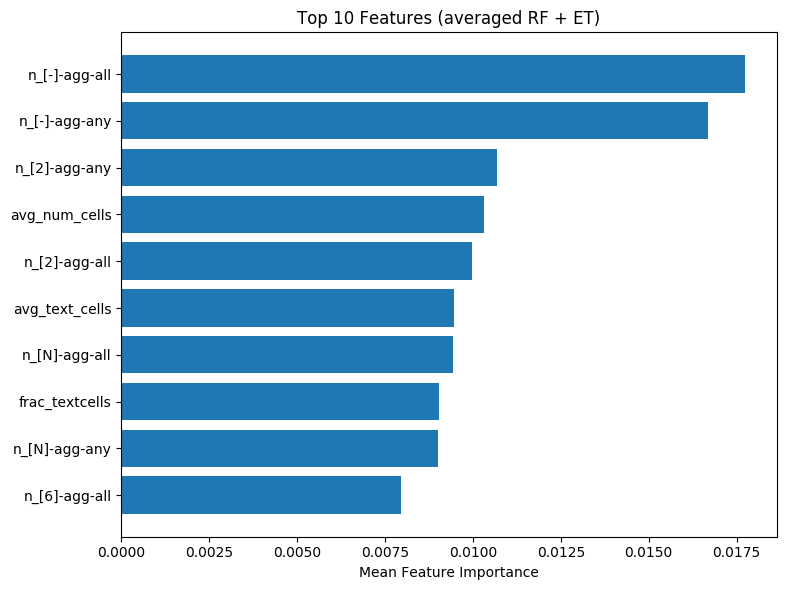

In [30]:
# 5) Plot
plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'].head(10)[::-1],
         imp_df['avg'].head(10)[::-1])
plt.xlabel("Mean Feature Importance")
plt.title("Top 10 Features (averaged RF + ET)")
plt.tight_layout()
plt.show()

### Predictions custom

In [21]:
data = pd.Series(
    [
        ["2024-02-30", "2020-03-01", "1982-12-30"],
        ["104805", "330956", "345609"],
        ["Male", "Female"],
        ["men", "women"],

    ],
    name="values"
)

In [22]:
data

0    [2024-02-30, 2020-03-01, 1982-12-30]
1                [104805, 330956, 345609]
2                          [Male, Female]
3                            [men, women]
Name: values, dtype: object

In [23]:
from sherlock.features.preprocessing import extract_features

extract_features(
    "../check.csv",
    data
)
feature_vectors = pd.read_csv("../check.csv", dtype=np.float32)

unable to import 'smart_open.gcs', disabling that module
Extracting Features:   0%|          | 0/4 [00:00<?, ?it/s]

Initialising word embeddings


Extracting Features:   0%|          | 0/4 [00:02<?, ?it/s]

Initialise Word Embeddings process took 0:00:02.818674 seconds.


NameError: name 'model' is not defined

In [39]:
feature_vectors

,n_[0]-agg-any,n_[0]-agg-all,n_[0]-agg-mean,n_[0]-agg-var,n_[0]-agg-min,n_[0]-agg-max,n_[0]-agg-median,n_[0]-agg-sum,n_[0]-agg-kurtosis,n_[0]-agg-skewness,...,par_vec_390,par_vec_391,par_vec_392,par_vec_393,par_vec_394,par_vec_395,par_vec_396,par_vec_397,par_vec_398,par_vec_399
0,1.0,1.0,2.666667,1.555556,1.0,4.0,3.0,8.0,-1.5,-0.381802,...,0.000482,-0.000699,0.000464,0.000695,0.000377,0.000414,-0.000623,-0.000379,-0.000771,-0.000442
1,1.0,1.0,1.333333,0.222222,1.0,2.0,1.0,4.0,-1.5,0.707107,...,0.000800,0.000959,0.000994,0.000532,0.000768,0.000870,-0.000838,-0.000695,0.000956,0.000615
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-3.0,0.000000,...,-0.024608,-0.009890,-0.016155,0.000928,-0.008309,-0.015509,-0.020144,-0.037095,-0.001885,-0.040874
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-3.0,0.000000,...,-0.072729,-0.022693,-0.110678,0.089974,-0.099107,-0.090429,-0.001951,-0.008750,0.021203,-0.082619


In [44]:
train_columns_means = pd.DataFrame(feature_vectors.mean()).transpose()
feature_vectors.fillna(train_columns_means.iloc[0], inplace=True)

In [45]:
model = rf_clf
#predicted_labels = model.predict(data)

# 1) Ensemble predictions on training set
y_pred_ensemble = voting_clf.predict(feature_vectors)

print(y_pred_ensemble)

# 2) RandomForest‐only predictions on training set
#y_pred_rf = rf_clf.predict(X_train)

['date_report' 'id' 'outcome' 'pre_existing_condition']


### ETC Error analysis

In [23]:
import numpy as np
import pandas as pd

# 1. Get probabilities and turn them into labels
probs = et_clf.predict_proba(X_test)               # shape (n_samples, n_classes)
preds = predicted_labels(probs, le)                # your helper that maps probs→class

# 2. Make a small DataFrame to hold everything
df = pd.DataFrame({
    "true":   y_test,
    "pred":   preds,
})
# 3. Attach each class‐probability as its own column
for idx, cls in enumerate(le.classes_):
    df[f"prob_{cls}"] = probs[:, idx]

# 4. Flag the mistakes
df["correct"] = (df["true"] == df["pred"])

# 5. Slice out just the errors
errors = df[df["correct"] == False]

# 6. (Optionally) sort by how “confidently wrong” it was
#    i.e. predicted‐prob minus true‐prob
errors["confidence_gap"] = errors.apply(
    lambda row: row[f"prob_{row['pred']}"] - row[f"prob_{row['true']}"], axis=1
)
errors = errors.sort_values("confidence_gap", ascending=False)

# 7. Inspect
print(f"Total errors: {len(errors)} / {len(df)}")
print(errors[[
                 "true",
                 "pred",
                 "confidence_gap",
             ] + [f"prob_{cls}" for cls in le.classes_]].head(10))

Total errors: 19 / 107
                      true                    pred  confidence_gap  prob_age  \
11  pre_existing_condition         medical_boolean        1.000000      0.00   
92         medical_boolean                symptoms        1.000000      0.00   
2          medical_boolean                symptoms        0.750000      0.00   
42         medical_boolean                symptoms        0.750000      0.00   
71         medical_boolean  pre_existing_condition        0.600000      0.00   
32         contact_setting                symptoms        0.454545      0.00   
66         medical_boolean                    date        0.367222      0.15   
27                location         medical_boolean        0.265278      0.01   
77  pre_existing_condition             case_status        0.263333      0.00   
76                location         medical_boolean        0.222500      0.03   

    prob_case_status  prob_contact_setting  prob_date  prob_gender  prob_id  \
11             0.

/opt/miniconda3/envs/rosetta/lib/python3.7/site-packages/ipykernel_launcher.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
